# Homework 3 - Financial Transactions

## Data Quality Issues & Remediation
During the initial extraction and loading phases, several data quality issues were identified and resolved to ensure accurate reporting:

Formatting Anomalies: The raw CSV files contained invisible whitespaces in column headers and completely empty phantom columns (e.g., Unnamed: 5). These were systematically stripped and dropped.

Phantom Rows: Empty rows at the end of the transaction files were identified and removed dynamically by ensuring the Symbol column was populated.

Geographic Naming Inconsistencies: Country names varied significantly across datasets (e.g., "United Kingdom of Great Britain and Northern Ireland" vs. "United Kingdom", issues with Asian/Middle Eastern characters like "Türkie" or "Taiwan"). A standardized mapping dictionary was applied universally to both the geography dimension and the symbol dimension to prevent NaN values during table merges.

Missing Master Data : Approximately 18 ticker symbols were present in the transaction history but missing from the master symbol directory. To preserve financial history without losing data, "stub records" were dynamically generated, assigning these tickers to an "Unknown" sector, industry, and country.

Case Sensitivity: Inconsistencies in column casing (e.g., Date vs. date, TransactionType vs. transactiontype) caused pipeline failures. This was resolved by forcing a strict lowercase naming convention across all sanitized datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def clean_base_datasets(dim_symbol: pd.DataFrame, dim_geo: pd.DataFrame, fact_transactions: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    CLEANING FUNCTION
    ITS GOAL IS TO DELETE NULL VALUES AND STANDARDIZE THE NAME ACROSS COUNTRY
    """
    # TO WORK IN SAFETY I WORK WITH COPY OF FILES
    dim_symbol = dim_symbol.copy()
    dim_geo = dim_geo.copy()
    fact_transactions = fact_transactions.copy()

    # ==========================================
    # --- CLEANING (TRANSACTIONS) ---
    # ==========================================  
    fact_transactions.columns = fact_transactions.columns.str.strip() # DELETE THE WHITE SPACE IN THE COLOUMNS
    
    # Elimina le colonne completamente vuote (es. la famosa 'unnamed: 5')
    fact_transactions = fact_transactions.dropna(axis=1, how='all') # DELETE THE NULL COLUMN 
    
    if 'Symbol' in fact_transactions.columns:
        fact_transactions = fact_transactions.dropna(subset=['Symbol']) # DELETE ONLY THE ROWS WITH MISSING SYMBOL


    correzioni_paesi = {
        'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
        'United States of America': 'United States',
        'Netherlands, Kingdom of the': 'Netherlands',
        'Virgin Islands (British)': 'British Virgin Islands'
    }
    
    if 'name' in dim_geo.columns: # USING .ILOC TO CHANGE DIRECTLY THE NAME OF THE COUNTRY CONTAIN 'TAIWAN & TUR IN DIM_GEO
        dim_geo.loc[dim_geo['name'].str.contains('Taiwan', na=False), 'name'] = 'Taiwan' 
        dim_geo.loc[dim_geo['name'].str.contains('Tür', na=False), 'name'] = 'Turkey'
        dim_geo['name'] = dim_geo['name'].replace(correzioni_paesi)

    
    if 'country' in dim_symbol.columns: # DOING THE SAME CHANGES IN THE DIM_SYMBOL 
        dim_symbol.loc[dim_symbol['country'].str.contains('Taiwan', na=False), 'country'] = 'Taiwan'
        dim_symbol.loc[dim_symbol['country'].str.contains('Tür', na=False), 'country'] = 'Turkey'
        dim_symbol['country'] = dim_symbol['country'].replace(correzioni_paesi)


    # Ritorna i 3 dataset puliti
    return dim_symbol, dim_geo, fact_transactions

# Modeling Choices & Architecture
A dedicated Python function (clean_base_datasets) was engineered strictly for data sanitization (handling nulls and standardizing text). This decoupled the ETL cleaning phase from the database modeling phase.

From Pure Star Schema to Flat Table: Initially, the data was modeled using a strict Star Schema, generating surrogate keys (symbol_key, date_key, etc.) and moving all descriptive text into separate dimension tables (dim_time, dim_symbol, etc.).

I recognized that a strict Star Schema required complex, repetitive .merge() operations for every query, leading to column duplication (_x, _y suffixes). We pivoted to a Denormalized Flat Table approach. The final fact table was enriched with essential descriptive columns (year, quarter, transactiontype, sector, country). This choice drastically improved query performance, readability, and eliminated merge conflicts, making it highly optimized for frontend filtering.

In [ ]:
# --- LOAD DATA ---
symbols = pd.read_csv('symbols.csv' , sep=';')
transactions = pd.read_csv('account-statement-1-1-2024-12-31-2024.csv', sep=';')
geo = pd.read_csv('country.csv', sep=',')

# CLEAN by using the previous function that:
    # eliminate phantom cloums, chaged name for soma country
df_sym_clean, df_geo_clean, df_txn_clean = clean_base_datasets(symbols, geo, transactions)

# casting the colum into a dataframe
df_txn_clean['Date'] = pd.to_datetime(df_txn_clean['Date'], format="%d/%m/%Y %H:%M:%S", errors='coerce')

dim_time = df_txn_clean[['Date']].dropna().drop_duplicates().copy() 

dim_time['date_key'] = dim_time['Date'].dt.strftime('%Y%m%d').astype(int) 
dim_time['day'] = dim_time['Date'].dt.day
dim_time['month'] = dim_time['Date'].dt.month
dim_time['quarter'] = dim_time['Date'].dt.quarter
dim_time['year'] = dim_time['Date'].dt.year

# -------------------------------------------- #
# CREATION OF THE INDEX FOR THE DIFFERENT UNIQUE VALUE INSIDE DIM_SYMBOL , DIM_GEO AND DIM_TYPE
dim_symbol = df_sym_clean.copy()
dim_symbol['symbol_key'] = range(1, len(dim_symbol)+1) # surrogate key in an ETL pipeline
# -------------------------------------------- #
dim_geo = df_geo_clean[['name', 'region', 'sub-region']].drop_duplicates()
dim_geo['geo_key'] = range(1, len(dim_geo)+1)
# -------------------------------------------- #
dim_type = transactions[['TransactionType']].drop_duplicates().dropna().copy()
dim_type = dim_type.rename(columns={'TransactionType': 'type'})
dim_type['type_key'] = range(1, len(dim_type)+1)
# -------------------------------------------- #


dim_time.columns = dim_time.columns.str.lower()
dim_symbol.columns = dim_symbol.columns.str.lower()
dim_geo.columns = dim_geo.columns.str.lower()
df_txn_clean.columns = df_txn_clean.columns.str.lower()




In [ ]:
# ============================================ #
# BUILDING OF THE FACT TABLE
# ============================================ #

# starting with df_txn_clean that represent every transaction that are made, keeping all the informations
fact = df_txn_clean.copy()

fact = fact.merge(dim_time[['date', 'date_key']], on='date', how='left') # left join with dim_time on date 

fact = fact.merge(
    dim_type[['type', 'type_key']], # left join with dim_type on transaction.transactiontype = dim_type.type_key
    left_on='transactiontype', 
    right_on='type', 
    how='left'
)

fact = fact.merge(
    dim_symbol[['symbol', 'symbol_key', 'country']], # left join with symbol on transaction.symbols = symbols.symbol
    on='symbol', 
    how='left'
)

fact = fact.merge(
    dim_geo[['name', 'geo_key']], # left join with dim_geo on transaction.country = dim_geo.name
    left_on='country', 
    right_on='name', 
    how='left'
)

# ============================================ #
# FINAL CLEANING OF THE STAR SCHEMA
# ============================================ #
# in order to optimize the loading and filtering process i keep only the primary and foreign key in the star schema
# in other words i delete from the star schema the additional information keeping only the indetifiers (int)   

colonne_da_eliminare = [ 'transactiontype', 'country' , 'symbol', 'name', 'date', 'type']

# using list comprhention to operate on the fact structure
# fact = fact.drop(columns=[col for col in colonne_da_eliminare if col in fact.columns])
# but is better working with native function of pandas like, errors='ignore'
fact = fact.drop(columns=colonne_da_eliminare, errors='ignore')

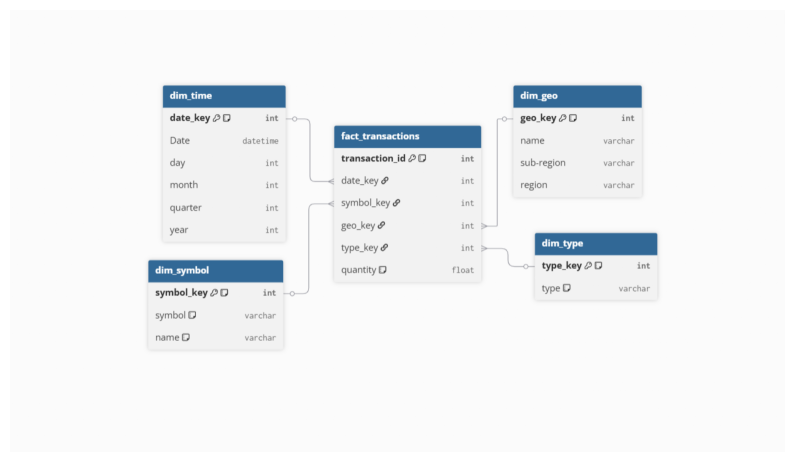

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('star.png')

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

In [185]:
# to formulate better the next queries 
valid_trades = ['BUY', 'SELL']
all_trades = ['BUY', 'SELL', 'DIVIDENT'] 

## what are the top 5 sectors by number of sell transaction in US during 2024
To solve this question i filtered before on the primary and referencial keys before doing the merge with the other dimentions.
The output shows that the best sector, is Technology with 3 times the numbers of SELL transactions of the others sectors in USA (2024) ; Also Financial Services, Communication Servicies, Consumer Cyclical and Healt-Care show the same absolute level of transactions.

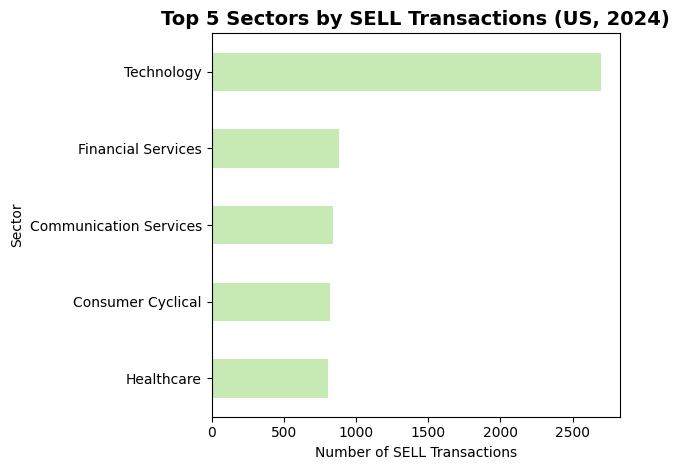

In [ ]:
# What are the top 5 sectors by number of SELL transactions in US during 2024?
# Filter the dimensions FIRST in order to optimize the usage of the RAM
filtered_type = dim_type[dim_type['type'] == 'SELL']
filtered_geo = dim_geo[dim_geo['name'] == 'United States']
filtered_time = dim_time[dim_time['year'] == 2024]

# merge only the filtered dimensions with the fact table
# Because pandas defaults to 'inner' joins, this automatically filters the fact table
q1 = fact.merge(filtered_type, on='type_key') \
              .merge(filtered_geo, on='geo_key') \
              .merge(filtered_time, on='date_key')

# bring in the EXACT columns you need from the final dimension
q1 = q1.merge(dim_symbol[['symbol_key', 'sector']], on='symbol_key')

# Aggregate
q1_result = q1.groupby('sector').size().sort_values(ascending=False).head(5)

# generate the graph directly from the series
q1_result.plot(kind='barh', color='#c7e9b4').invert_yaxis() # flip the axis

plt.title("Top 5 Sectors by SELL Transactions (US, 2024)", fontsize=14, fontweight='bold')
plt.xlabel("Number of SELL Transactions")
plt.ylabel("Sector")
plt.tight_layout() 

plt.show()

## What are the top 5 industries by number of BUY transactions in Q4 of 2024?
Filtering directly the dim_type and tim_geo and using them to get exactly the information about the subset of interest; and at the end grouping by the industries.
Semiconductors appears in the first place in terms of numbers of BUY transacrtion in the last three months of 2024, in the second place there is the Internet Content & Information industry, meanwile Internet Retail , Software - Infrastructure and Diagnostics & research shows the same number of transactions around 65 and 90. Due to the hype and high demand of software servicies we couldn't help but expect Semiconductors to be the giant  compared to the other sector. In fact the other industries to stay alive need the harware structure behind.


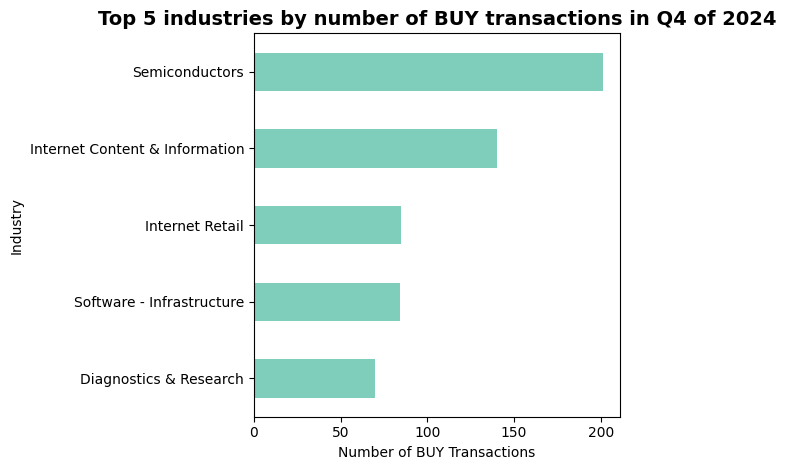

In [ ]:
# What are the top 5 industries by number of BUY transactions in Q4 of 2024?
filtered_type = dim_type[dim_type['type'] == 'BUY']
filtered_time = dim_time[(dim_time['quarter'] == 4) & (dim_time['year'] == 2024)]

q2 = fact.merge(filtered_type, on='type_key') \
              .merge(filtered_time, on='date_key')

q2 = q2.merge(dim_symbol[['symbol_key', 'industry']], on='symbol_key')

q2_result = q2.groupby('industry').size().sort_values(ascending=False).head(5)

q2_result.plot(kind='barh', color='#7fcdbb').invert_yaxis() 

plt.title("Top 5 industries by number of BUY transactions in Q4 of 2024", fontsize=14, fontweight='bold')
plt.xlabel("Number of BUY Transactions")
plt.ylabel("Industry")
plt.tight_layout() 

plt.show()

### Rank all quarters of 2024 buy total number of transactions
Looking at the histogram the first three months of the 2024 are the most active in absolute in terms of ferment and activity. Also this time i used the filter dimentions : time(2024) and type_of_transaction(BUY+SELL), and after apply the merge with fact_table only on the filtered subset and obtain the other information.  

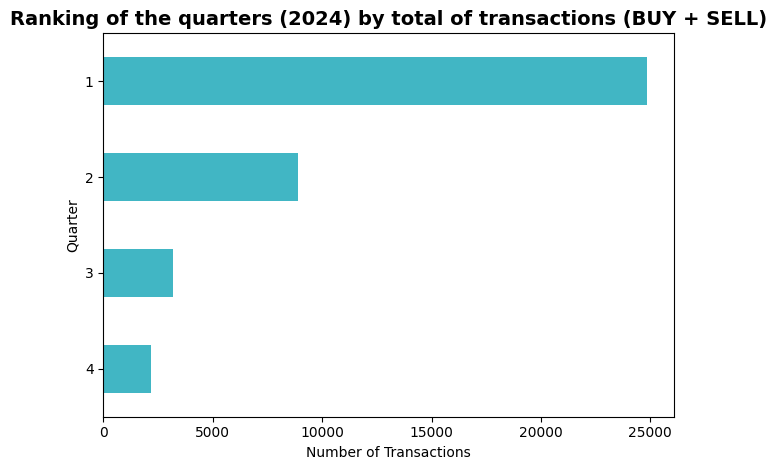

In [205]:
# Rank all quarters of 2024 by total number of transactions (BUY + SELL)
# Filter
filtered_time = dim_time[dim_time['year'] == 2024]
filtered_type = dim_type[dim_type['type'].isin(valid_trades)]

# Merge
q3_fast = fact.merge(filtered_type[['type_key']], on='type_key') \
              .merge(filtered_time[['date_key', 'quarter']], on='date_key')

# Aggregate
q3_result = q3_fast.groupby('quarter').size().sort_values(ascending=False)

q3_result.plot(kind='barh', color='#41b6c4').invert_yaxis() 

plt.title("Ranking of the quarters (2024) by total of transactions (BUY + SELL)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Transactions")
plt.ylabel("Quarter")
plt.tight_layout() 

plt.show()

# What are the top 5 sectors by total units traded (BUY + SELL) in Q3 of 2024?
The Technology sector dominates the chart, being the only sector to surpass the 50,000-unit mark. [first place]

Consumer Cyclical follows in second place, with trading volume approaching 40,000 units.

Financial Services and Communication Services hold the third and fourth positions, respectively. Both sectors show similar trading volumes, hovering just slightly above 30,000 units.

Lowest of the Top 5: Healthcare ranks fifth, with its trading volume landing just below the 30,000-unit threshold.

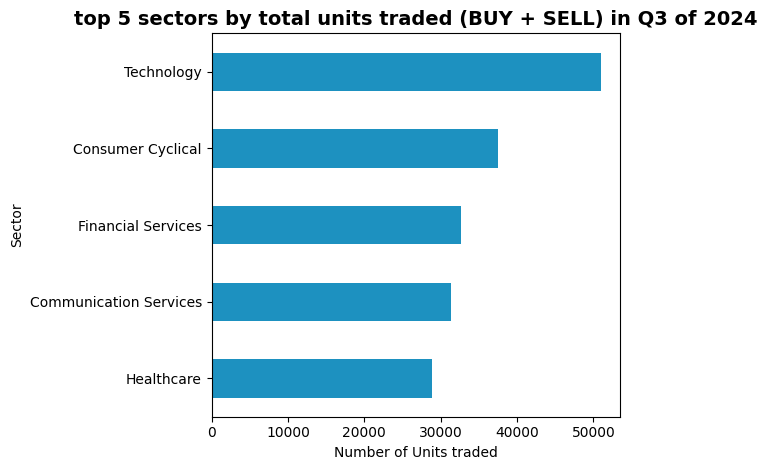

In [206]:
# What are the top 5 sectors by total units traded (BUY + SELL) in Q3 of 2024?
filtered_time = dim_time[(dim_time['year'] == 2024) & (dim_time['quarter'] == 3)]

# Prendiamo solo BUY e SELL
filtered_type = dim_type[dim_type['type'].isin(valid_trades)]


# 2. IL TUO STAR JOIN MAGICO
# Uniamo la tabella fact SOLO con le chiavi filtrate. 
# Aggiungiamo anche dim_symbol per recuperarci il nome del 'sector' che ci serve per il grafico!
q6_fast = fact.merge(filtered_type[['type_key']], on='type_key') \
              .merge(filtered_time[['date_key']], on='date_key') \
              .merge(dim_symbol[['symbol_key', 'sector']], on='symbol_key') 


q6_result = q6_fast.groupby('sector')['unit'].sum().sort_values(ascending=False).head(5)


q6_result.plot(kind='barh', color='#1d91c0').invert_yaxis() 

plt.title("top 5 sectors by total units traded (BUY + SELL) in Q3 of 2024", fontsize=14, fontweight='bold')
plt.xlabel("Number of Units traded")
plt.ylabel("Sector")
plt.tight_layout() 

plt.show()

For the last queries i decide to use the not optimeze approach, only beacause i want to explore the both way, the output are the same of the optimal way change only the amount of RAM used changed. 

# What are the top 10 symbols by number of transactions (BUY + SELL) in 2024?
ARM clearly dominates the chart. It is the only symbol to cross the 2,000-transaction threshold, sitting at roughly 2,250 transactions for the year.

The upper half of the chart shows massive trading interest in semiconductor and hardware manufacturing. Behind ARM, AMD  and TSM  secure strong positions in the top four.

There is a significant gap between the top four actively traded symbols and the rest of the list. After TSM, the transaction volume drops steeply, cutting nearly in half.

The remaining symbols—EH, ARDX, GOOG, APP, MSFT, and AMZN—are grouped closely together. They all fall within a much narrower range, logging between approximately 700 and 900 transactions each. Interestingly, widely recognized mega-cap tech giants like Microsoft (MSFT) and Amazon (AMZN) sit at the very bottom of this top 10 list.

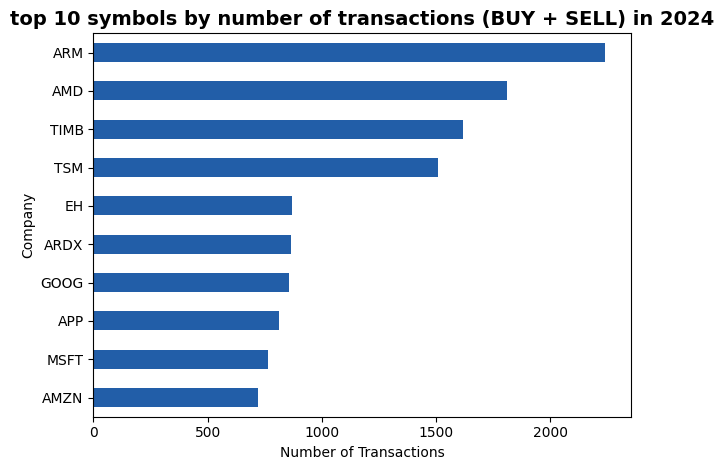

    symbol                        industry
14     ARM                  Semiconductors
9      AMD                  Semiconductors
99    TIMB                Telecom Services
102    TSM                  Semiconductors
43      EH             Aerospace & Defense
13    ARDX                   Biotechnology
49    GOOG  Internet Content & Information
12     APP          Software - Application
69    MSFT       Software - Infrastructure
11    AMZN                 Internet Retail


In [ ]:
# What are the top 10 symbols by number of transactions (BUY + SELL) in 2024?
q7 = fact.merge(dim_time[['date_key', 'quarter', 'year']], on='date_key') \
         .merge(dim_symbol, on='symbol_key') \
         .merge(dim_type, on='type_key')

q7_filtered = q7[(q7['year'] == 2024) & (q7['type'].isin(valid_trades))]
q7_result = q7_filtered.groupby('symbol').size().sort_values(ascending=False).head(10)

q7_result.plot(kind='barh', color='#225ea8').invert_yaxis() 

plt.title("top 10 symbols by number of transactions (BUY + SELL) in 2024", fontsize=14, fontweight='bold')
plt.xlabel("Number of Transactions")
plt.ylabel("Company")
plt.tight_layout() 

plt.show()

# differently than before i group by symbol and industry, this produced an MultiIndex Series with the firt layer of index related to symbol and the second-one layer works on industries
    # .reset_index(name='transactions) takes the multiIndex and flattens it transformig both into a normal columns of a new data-frame
        # insted of calling 0 the coloumn of index now it is called transactions
q7_result = q7_filtered.groupby(['symbol', 'industry']).size().reset_index(name='transactions')
top_10_players = q7_result.sort_values(by='transactions',ascending=False).head(10)
print(top_10_players[['symbol','industry']])

# What are the top 3 sectors by total number of units sold on Mondays across 2024?
The Technology sector is the undisputed leader in Monday sales volume. At approximately 75,000 units sold, it drastically outperforms the other sectors.

Healthcare holds the second position with roughly 26,000 units sold, followed by Communication Services in third place with nearly 20,000 units.

The most striking feature of the graph is the massive gap between first and second place. The Technology sector's Monday sales volume is nearly three times higher than that of the Healthcare sector, indicating highly concentrated trading or sales activity in tech at the start of the week.

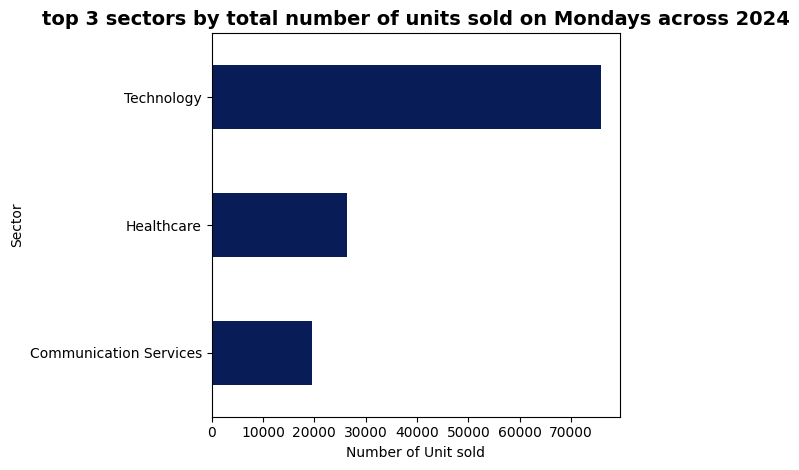

In [208]:
# What are the top 3 sectors by total number of units sold on Mondays across 2024?
q12 = fact.merge(dim_type, on='type_key') \
          .merge(dim_time, on='date_key') \
          .merge(dim_symbol, on='symbol_key')

q12_filtered = q12[(q12['type'] == 'SELL') & 
                   (q12['year'] == 2024) & 
                   (q12['date'].dt.dayofweek == 0)] # 0 = Lunedì

q12_result = q12_filtered.groupby('sector')['unit'].sum().sort_values(ascending=False).head(3)

q12_result.plot(kind='barh', color='#081d58').invert_yaxis() 
plt.title("top 3 sectors by total number of units sold on Mondays across 2024", fontsize=14, fontweight='bold')
plt.xlabel("Number of Unit sold")
plt.ylabel("Sector")
plt.tight_layout() 
plt.show()